# Nowcasting Autoencoder Tutorial

Creating an effective autoencoder is a great first step in developing a predictive model. Learning how to create a high-quality latent state is critical, and can later be used to train a new encoder for a pre-existing predictive model, or a new decoder. An example for this could be training an encoder which uses different or fewer variables than the original model. Another might be training a higher-resolution decoder which is capable of producing higher-resolution predictions from the same latent state.

This tutorial present a simple architecture which is suitable for a first step in learning how to build an autoencoder, and can be extended to produce higher-quality images in future exercises.

Autoencoders are also a great concept to learn when understanding neural network architectures.

In this example, we first blend radar and satellite data onto the same grid, then train an autoencoder to perform dimensionality reduction and produce a useful latent state which can be used to resonstruct the original inputs.

In [1]:
import sys

userbase = "/g/data/v46/txs156/"
petbase = "PyEarthTools/packages"

base = userbase + petbase

sys.path.insert(0, f"{base}/data/src")
sys.path.insert(0, f"{base}/pipeline/src")
sys.path.insert(0, f"{base}/nci_site_archive/src")
sys.path.insert(0, f"{base}/utils/src")  # if needed

import pyearthtools.data as petdata
from pyearthtools.data.transforms import TransformCollection
import pyearthtools.pipeline as petpipe
import site_archive_nci
import pyearthtools.data.archive as arch
from pyearthtools.data.indexes import DataFileSystemIndex
import numpy as np
import pandas as pd

from pyearthtools.data.time import Petdt
from pyearthtools.pipeline.operations.xarray.join import GeospatialTimeSeriesMerge

import xarray as xr

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt
import datetime
# Set random seed for reproducibility
torch.manual_seed(42)

# Autodetect GPU and use if possible
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")



In [2]:
xr.open_dataset(userbase+"OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")

<xarray.Dataset> Size: 198MB
Dimensions:                 (yt_ocean: 300, xt_ocean: 360, time: 228)
Coordinates:
  * xt_ocean                (xt_ocean) float64 3kB -279.5 -278.5 ... 78.5 79.5
  * yt_ocean                (yt_ocean) float64 2kB -77.88 -77.63 ... 89.32 89.77
    geolat_t                (yt_ocean, xt_ocean) float32 432kB ...
    geolon_t                (yt_ocean, xt_ocean) float32 432kB ...
  * time                    (time) datetime64[ns] 2kB 2000-01-14T12:00:00 ......
Data variables:
    area_t                  (yt_ocean, xt_ocean) float32 432kB ...
    total_surface_heat_flx  (time, yt_ocean, xt_ocean) float32 98MB ...
    ocean_heat_content_2d   (time, yt_ocean, xt_ocean) float32 98MB ...

In [5]:
from pathlib import Path
from typing import Any
import pyearthtools.data.archive as archive

@archive.register_archive(
    "ACCESS_OHC",
    sample_kwargs=dict(
        variables="ocean_heat_content_2d",
        root=userbase + "OM2-emulator/data/",
    ),
)
class ACCESS_OHC(DataFileSystemIndex):
    """User-defined ACCESS Ocean Heat Content archive."""

    @property
    def _desc_(self):
        return {
            "singleline": "ACCESS Ocean Heat Content (user extension)",
            "Range": "2000–2018",
            "Resolution": "1-degree",
        }

    def __init__(
        self,
        variables: str | list[str],
        *,
        root: str | Path,
        transforms=None,
        **kwargs: Any,
    ):
        self.variables = [variables] if isinstance(variables, str) else list(variables)
        self.root = Path(root)

        base = petdata.transforms.variables.Trim(self.variables)

        super().__init__(
            transforms=base + (transforms or TransformCollection()),
            **kwargs,
        )
        self.record_initialisation()

    def search(self, *args, **kwargs):
        """
        Ignore time entirely: dataset is time-complete.
        """
        path = self.root / "1deg_ocean_heat_emulator_data.nc"
        if not path.exists():
            raise DataNotFoundError(f"ACCESS_OHC file not found at {path!r}")

        # Map each requested variable to the same file
        return {v: path for v in self.variables}

    def get(self, querytime, **kwargs):
        path = self.root / "1deg_ocean_heat_emulator_data.nc"
        if not path.exists():
            raise DataNotFoundError(f"ACCESS_OHC file not found at {path!r}")
    
        ds = xr.open_dataset(path)
    
        # Keep only requested variables
        keep = [v for v in self.variables if v in ds.data_vars]
        if keep:
            ds = ds[keep]
    
        qt = str(querytime)
    
        # -------------------------
        # Case 1: "YYYY" → full year
        # -------------------------
        if len(qt) == 4 and qt.isdigit():
            start = pd.Timestamp(f"{qt}-01-01")
            end = pd.Timestamp(f"{int(qt)+1}-01-01")
            return ds.sel(time=slice(
                np.datetime64(start),
                np.datetime64(end),
            ))
    
        # -------------------------
        # Case 2: "YYYY-MM" → month
        # -------------------------
        if len(qt) == 7 and qt[4] == "-":
            start = pd.Timestamp(f"{qt}-01")
            end = start + pd.offsets.MonthBegin(1)
            return ds.sel(time=slice(
                np.datetime64(start),
                np.datetime64(end),
            ))
    
        # -------------------------
        # Case 3: exact datetime → nearest
        # -------------------------
        qt_dt = np.datetime64(str(Petdt(querytime)))
        return ds.sel(time=qt_dt, method="nearest")


In [6]:
ACCESS_OHC = archive.ACCESS_OHC(
    ["area_t", "ocean_heat_content_2d", "total_surface_heat_flx"],
    root=userbase + "OM2-emulator/data/",
)

satpipe = petpipe.Pipeline(
    ACCESS_OHC,
    iterator=petpipe.iterators.DateRange(2000, 2018, interval='1 month')
)

# We specify the date, hour, and minute for querying data
doi = "2001"
ACCESS_sample = satpipe[doi]

In [8]:
%%time
ipipe = iter(satpipe)  # Make an iterator to walk the time period
# Takes around 15 seconds per sample to retrieve, largely due to the zip compression used on-disk
merged_sample = next(ipipe)
merged_sample

CPU times: user 113 ms, sys: 4.97 ms, total: 118 ms
Wall time: 117 ms


<xarray.Dataset> Size: 2MB
Dimensions:                 (latitude: 300, longitude: 360, time: 1)
Coordinates:
  * longitude               (longitude) float64 3kB -279.5 -278.5 ... 78.5 79.5
  * latitude                (latitude) float64 2kB -77.88 -77.63 ... 89.32 89.77
    geolat_t                (latitude, longitude) float32 432kB ...
    geolon_t                (latitude, longitude) float32 432kB ...
  * time                    (time) datetime64[ns] 8B 2000-01-14T12:00:00
Data variables:
    area_t                  (latitude, longitude) float32 432kB ...
    total_surface_heat_flx  (time, latitude, longitude) float32 432kB ...
    ocean_heat_content_2d   (time, latitude, longitude) float32 432kB ...

In [ ]:
def broadcast_static_to_time(ds):
    if "area_t" in ds and "time" in ds.coords and "time" not in ds["area_t"].dims:
        ds["area_t"] = ds["area_t"].expand_dims(time=ds["time"]).transpose("time", "latitude", "longitude")
    return ds

full = petpipe.Pipeline(
    (satpipe),
    # GeospatialTimeSeriesMerge(reference_dataset=ACCESS_sample), # These are pretty similar grids, so just pick one
    petdata.transforms.coordinates.Drop(['geolat_t', 'geolon_t']),
    petdata.transforms.variables.Drop(['area_t']),
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  # Align data variables coordinate ordering to dataset coordinate ordering
    # petdata.transform.region.Bounding(-40, -25, 135, 152),  # cut down on region for example
    petpipe.operations.xarray.conversion.ToNumpy(),
    # petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('2000-01', '2001-01', interval='1 month')
)
full

ipipe = iter(full)  # Make an iterator to walk the time period
full.exceptions_to_ignore
n = next(ipipe)

In [55]:
np.nansum(n[0,0,:,:])
np.nansum(n[1,0,:,:])

np.float32(2.600972e+17)

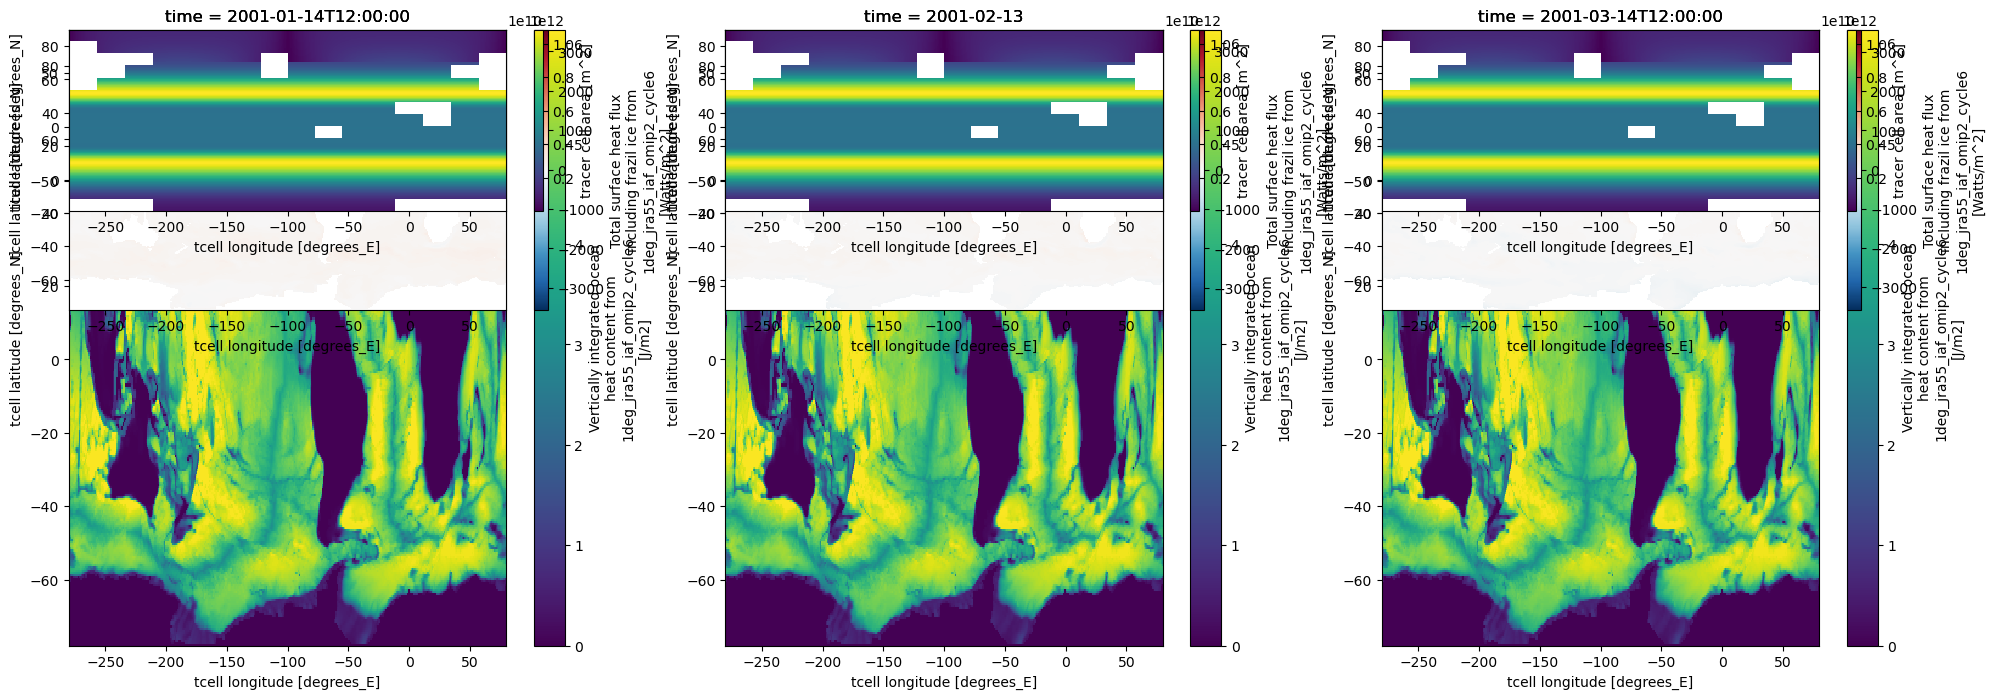

In [31]:
from dateutil.relativedelta import relativedelta

fig1 = plt.figure('sidebyside_OHC', figsize=(24,8))
for ix1 in range(3):
    ax1 = fig1.add_subplot(1,3,ix1+1)
    ax2 = fig1.add_subplot(2,3,ix1+1)
    ax3 = fig1.add_subplot(3,3,ix1+1)

    plot_time = pd.Timestamp(doi) + relativedelta(months=ix1)
    n[0,0,:,:].plot.imshow(ax=ax1)
    satpipe[plot_time]['total_surface_heat_flx'][:,:].plot.imshow(ax=ax2)
    satpipe[plot_time]['area_t'][:,:].plot.imshow(ax=ax3)

In [32]:
# Here we define an "AutoEncoder". This is a model which reproduces its inputs, 
# through a bottleneck layer. It is one of the primary concepts behind many 
# neural network architectures that you will work with in future, and is key to
# conceptual understanding as well as being sometimes useful in 

# Reminder, the image size is latitude: 1726, longitude: 2214

class AutoEncoder(nn.Module):
    def __init__(self, 
                 input_height = 501,
                 input_width = 601,
                 kernel_size = 4,
                 stride=2,
                 input_channel_count = 2,
                 output_channel_count = 2,
                 latent_dim=300):
        super(AutoEncoder, self).__init__()

        self.input_width = input_width
        self.input_height = input_height
        self.input_channel_count = input_channel_count
        self.output_channel_count = output_channel_count

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=self.input_channel_count, out_channels=16, kernel_size=kernel_size, stride = stride, padding = 1),
            nn.ReLU(),
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, stride =2, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=7),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=7),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=32, out_channels=16, kernel_size=3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=16, out_channels=self.output_channel_count, kernel_size=kernel_size, stride=stride, padding=1, output_padding=1),
            nn.Sigmoid()
        )
        

    def forward(self, x):

        # Get latent representation
        latent = self.encoder(x)

        # Reconstruct input
        reconstructed = self.decoder(latent)

        return reconstructed

In [59]:
# Initialize model and move to device
model = AutoEncoder(input_channel_count=1, output_channel_count=1).to(device)

# Loss function and optimizer
criterion = nn.L1Loss()
# criterion = nn.KLDivLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

In [60]:
x = torch.from_numpy(n).float().to(device)

In [61]:
# This should make us a messy prediction from an untrained model in the dimension of the input
prediction = model.forward(x)

In [62]:
image_numpy_for_display = prediction.to('cpu').detach().numpy()
# image_numpy_for_display

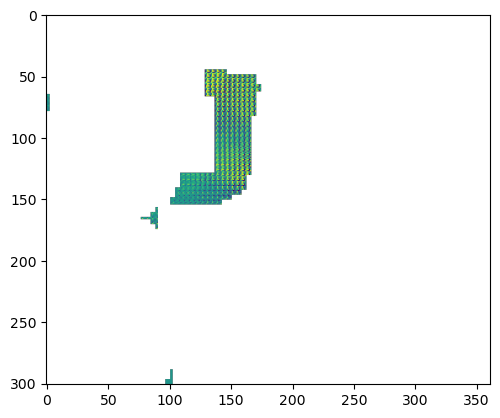

In [63]:
plt.imshow(image_numpy_for_display[0][0])

In [64]:
%%time

# 1000 samples is taking about 2 minutes
# It should be able to go much much much faster, but still we can test it and make progress
# Let's to 30 minutes of training, i.e. 15k samples

def train(debug=True, num_epochs=1, max_samples=10, print_per=20):
    # Training loop
    
    sample_ix = 0 
    
    
    for epoch in range(num_epochs):
        total_loss = 0    
        epoch_samples = 0
        ipipe = iter(full)  # Make an iterator to walk the time period
    
        while True:
            try:
                sample = next(ipipe)
            except StopIteration:
                break  # advance the epoch loop
            except:
                pass # some samples are just missing
    
            sample_ix += 1
            epoch_samples += 1
            if epoch_samples % print_per == 0:
                print(epoch_samples)
            
            if sample_ix > max_samples:
                break

            if debug:
                print(sample_ix)
    
            x = torch.from_numpy(sample).float().to(device)   

            if torch.any(torch.isnan(x)):
                # Skip nan inputs, they break the training
                continue
                
            if debug:
                print("Input")
                print(x)
    
            optimizer.zero_grad()
    
            # Forward pass
            y = model.forward(x)

            if debug:
                print("prediction")
                print(y)
            
            loss = criterion(y, x)
            if debug:
                print("loss")
                print(loss)
    
            # Backward pass and optimize        
            loss.backward()
            optimizer.step()
    
            total_loss += loss.item()
    
        # Print epoch statistics
        avg_loss = total_loss / epoch_samples
        epoch_samples = 0  # Reset for next epoch
        print(f'Epoch [{epoch+1}/{epoch_samples}], Average Loss: {avg_loss:.4f}')

train(debug=False, num_epochs=50, max_samples=15 * 1000, print_per = 500)

Epoch [1/0], Average Loss: 0.0000
Epoch [2/0], Average Loss: 0.0000
Epoch [3/0], Average Loss: 0.0000
Epoch [4/0], Average Loss: 0.0000
Epoch [5/0], Average Loss: 0.0000
Epoch [6/0], Average Loss: 0.0000
Epoch [7/0], Average Loss: 0.0000
Epoch [8/0], Average Loss: 0.0000
Epoch [9/0], Average Loss: 0.0000
Epoch [10/0], Average Loss: 0.0000
Epoch [11/0], Average Loss: 0.0000
Epoch [12/0], Average Loss: 0.0000
Epoch [13/0], Average Loss: 0.0000
Epoch [14/0], Average Loss: 0.0000
Epoch [15/0], Average Loss: 0.0000
Epoch [16/0], Average Loss: 0.0000
Epoch [17/0], Average Loss: 0.0000
Epoch [18/0], Average Loss: 0.0000
Epoch [19/0], Average Loss: 0.0000
Epoch [20/0], Average Loss: 0.0000
Epoch [21/0], Average Loss: 0.0000
Epoch [22/0], Average Loss: 0.0000
Epoch [23/0], Average Loss: 0.0000
Epoch [24/0], Average Loss: 0.0000
Epoch [25/0], Average Loss: 0.0000
Epoch [26/0], Average Loss: 0.0000
Epoch [27/0], Average Loss: 0.0000
Epoch [28/0], Average Loss: 0.0000
Epoch [29/0], Average Loss: 0

In [38]:
x.min()

tensor(0.2183, device='cuda:0')

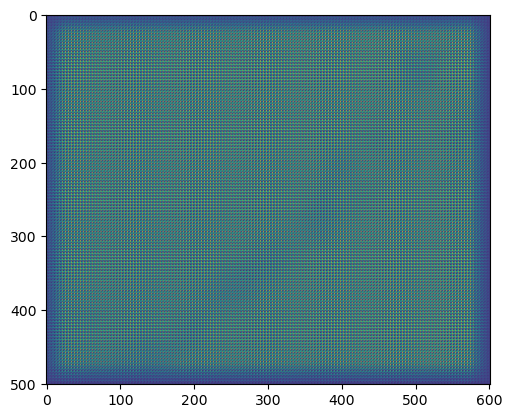

In [39]:
prediction = model.forward(x)
image_numpy_for_display = prediction.to('cpu').detach().numpy()
plt.imshow(image_numpy_for_display[0][0])

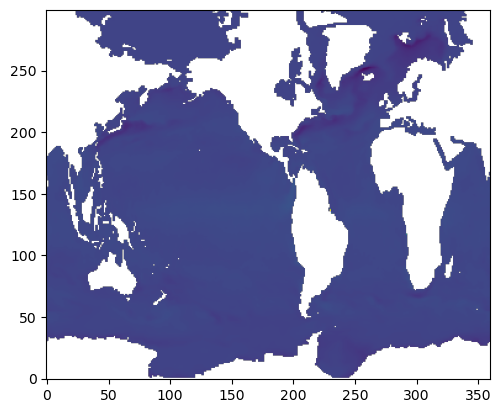

In [48]:

z = torch.from_numpy(full['2001-03']).float().to(device)

image_numpy_for_display = z.to('cpu').detach().numpy()
plt.imshow(image_numpy_for_display[0][0])
plt.gca().invert_yaxis()

In [42]:
latent = model.encoder(z)

In [43]:
latent.shape

torch.Size([2, 64, 69, 84])

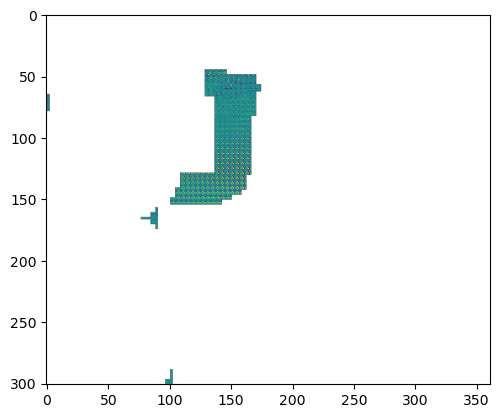

In [44]:
reconstruction = model.forward(z)
image_numpy_for_display = reconstruction.to('cpu').detach().numpy()
plt.imshow(image_numpy_for_display[0][0])